# Swan Teleco — Churn Analysis & Retention Recommendations

This notebook answers the four business questions from the brief, in order:

1. **Demographics of churners** — who is leaving (gender, age, family makeup), what products they hold, and why they churn.
2. **Retention factors and the £2.50 sign-up incentive** — which factors keep customers, and which single service the new-customer team should be paid to push.
3. **500 mailers** — the top 500 at-risk customers to target with the retention offer.
4. **Full customer risk list** — churn probability for every remaining customer, for the customer-service team.

The churn prediction model that powers Q3 and Q4 is built up front in Section 1 so it can be referenced by the later sections.

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay,
    make_scorer
)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.inspection import permutation_importance

# 0. EDA

In [2]:
df_raw = pd.read_excel("1 - Project Data.xlsx")

In [3]:
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 7,043 rows x 31 columns


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,Competitor had better devices


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
# Missing values and duplicates
missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "  (none detected by pandas isna — see Total Charges check below)")
print()
print(f"Fully duplicated rows: {df_raw.duplicated().sum()}")
print(f"Duplicated CustomerIDs: {df_raw['CustomerID'].duplicated().sum()}")

Columns with missing values:
Churn Reason    5174
dtype: int64

Fully duplicated rows: 0
Duplicated CustomerIDs: 0


In [6]:
card = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'n_unique': df_raw.nunique(),
    'pct_unique': (df_raw.nunique() / len(df_raw) * 100).round(1)
}).sort_values('n_unique', ascending=False)
card

,dtype,n_unique,pct_unique
CustomerID,object,7043,100.0
Total Charges,object,6531,92.7
Zip Code,int64,1652,23.5
Lat Long,object,1652,23.5
Latitude,float64,1652,23.5
Longitude,float64,1651,23.4
Monthly Charges,float64,1585,22.5
City,object,1129,16.0
Tenure Months,int64,73,1.0
Churn Reason,object,20,0.3


**Notes from the scan above:**
- `CustomerID` is a unique identifier — no analytical value, drop before modeling.
- `Count` is constant (always 1) — an artifact of the source export, drop.
- `Country`, `State` are constant (this extract is US/California only), drop.
- `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude` are high-cardinality geographic fields.
  Useful for a map visual in the deck, but a **memorization risk** for tree-based models if used raw.

## Data Quality

In [7]:
blank_mask = df_raw['Total Charges'].astype(str).str.strip() == ''
print(f"Blank 'Total Charges' rows: {blank_mask.sum()}")
df_raw.loc[blank_mask, ['CustomerID', 'Tenure Months', 'Monthly Charges', 'Total Charges']]

Blank 'Total Charges' rows: 11


,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,
2438,3115-CZMZD,0,20.25,
2568,5709-LVOEQ,0,80.85,
2667,4367-NUYAO,0,25.75,
2856,1371-DWPAZ,0,56.05,
4331,7644-OMVMY,0,19.85,
4687,3213-VVOLG,0,25.35,
5104,2520-SGTTA,0,20.00,
5719,2923-ARZLG,0,19.70,
6772,4075-WKNIU,0,73.35,


Total charges is stored as text and is blank for new customers, so we can replace these nulls with zeros.

In [8]:
print(df_raw.groupby('Churn Value')['Churn Reason'].apply(lambda s: s.notna().sum()))
print()
n_active = (df_raw['Churn Value'] == 0).sum()
n_churned = (df_raw['Churn Value'] == 1).sum()
print(f"Active (non-churned) customers: {n_active:,}  <- this is the deployment pool for targeting")
print(f"Churned customers:              {n_churned:,}")

Churn Value
0       0
1    1869
Name: Churn Reason, dtype: int64

Active (non-churned) customers: 5,174  <- this is the deployment pool for targeting
Churned customers:              1,869


Churn Reason only appears for customers that have churned, therefore must be dropped in modelling.

## Target variable

Overall churn rate: 26.5%  (1,869 of 7,043 customers)


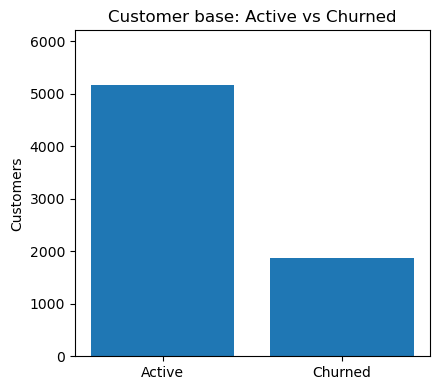

In [9]:
churn_rate = df_raw['Churn Value'].mean()
print(f"Overall churn rate: {churn_rate:.1%}  ({n_churned:,} of {len(df_raw):,} customers)")

fig, ax = plt.subplots(figsize=(4.5, 4))
counts = df_raw['Churn Value'].value_counts().sort_index()
bars = ax.bar(['Active', 'Churned'], counts.values)
ax.set_title('Customer base: Active vs Churned')
ax.set_ylabel('Customers')
ax.set_ylim(0, counts.max()*1.2)
plt.tight_layout()
plt.show()

Churn has a significant class imbalance, which will have to cosidered in the train/test split.

## Cleaning Function

In [10]:
cols_all = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
           'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
           'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
           'Multiple Lines', 'Internet Service', 'Online Security',
           'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
           'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
           'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
           'Churn Reason']


cols_drop = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Lat Long',
             'Latitude', 'Longitude', 'Churn Label', 'Churn Reason', 'Zip Code']

cols_keep = ['Phone Service', 'Internet Service', 'Total Charges', 'Paperless Billing', 
             'Partner', 'Online Backup', 'Multiple Lines', 'Monthly Charges', 'Churn Value',
             'Contract', 'Tech Support', 'Online Security', 'Device Protection',
             'Dependents', 'Senior Citizen', 'Gender', 'Streaming TV', 
             'Payment Method', 'Streaming Movies', 'Tenure Months']


target = ["Churn Value"]

cols_cat = ['Gender','Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 
            'Paperless Billing', 'Multiple Lines', 'Internet Service', 
            'Online Security', 'Online Backup', 'Device Protection',
            'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract',
            'Payment Method']

cols_num = ['Monthly Charges', 'Total Charges', 'Tenure Months']


cols_new = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Paperless Billing_Yes',
       'Multiple Lines_No phone service', 'Multiple Lines_Yes',
       'Internet Service_Fiber optic', 'Internet Service_No',
       'Online Security_No internet service', 'Online Security_Yes',
       'Online Backup_No internet service', 'Online Backup_Yes',
       'Device Protection_No internet service', 'Device Protection_Yes',
       'Tech Support_No internet service', 'Tech Support_Yes',
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check']

In [11]:
def clean(df, cols_drop, cols_cat, cols_num):

    # Make a copy 
    df = df.copy()
    
    # Drop columns we don't need
    df = df.drop(cols_drop, axis=1)

    # Convert Total Charges to numeric
    df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

    # Replace NaN with 0
    df = df.fillna(0)

    # One-hot encode categorical columns
    for col in cols_cat:
        dummies = pd.get_dummies(
            df[col],
            prefix=col,
            drop_first=True,
            dtype=int
        )
        df = pd.concat([df.drop(columns=col), dummies], axis=1)
        
    return df

In [12]:
df = clean(df_raw,cols_drop,cols_cat,cols_num)

# 1. Churn Prediction Model

Logistic Regression with grid-searched hyperparameters (C, L1/L2 penalty, class weighting), tuned on a stratified 80/20 split with 5-fold cross-validation on the training set only. `roc_auc` is the primary metric because churn is imbalanced (~26.5% positive class); F1, average precision, and a custom precision top-7.1% (the ~500-mailer slice) are tracked alongside for reference.

The fitted `best_model` and predicted probabilities from this section feed directly into **Section 4** (top-500 mailer list) and **Section 5** (full customer risk list).


In [13]:
"""
Grid search CV for the Logistic Regression churn model.
"""
X = df.drop(target, axis = 1)
y = df["Churn Value"]
# Stratified 80/20 split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [14]:
# --- Custom precision@k% scorer -------------------------------------------
# 500 out of the full 7,043 customers is ~7.1%. Since each CV fold is only a
# fraction of the training data, we scale k proportionally to the fold size
# rather than hardcoding 500 (which wouldn't fit inside a single fold).
TOP_K_FRACTION = 500 / 7043  # ~0.071

def precision_at_k_fraction(y_true, y_proba, k_fraction=TOP_K_FRACTION):
    y_true = np.asarray(y_true)
    n_top = max(1, int(round(len(y_true) * k_fraction)))
    top_idx = np.argsort(y_proba)[::-1][:n_top]
    return y_true[top_idx].mean()

precision_at_k_scorer = make_scorer(
    precision_at_k_fraction, response_method="predict_proba", greater_is_better=True
)

## Logistic Regression

In [15]:
# ---------------------------------------------------------------------------
# GRID SEARCH SETUP
# ---------------------------------------------------------------------------

# Adjust these two lists to match whatever's actually left in X_train's columns
# after your own cleaning/feature selection.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cols_num)
    ]
)

pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, random_state=42)),
    ]
)

# liblinear supports both l1 and l2 penalties, and handles this dataset size easily
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"],
    "clf__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# roc_auc / average_precision as the primary metrics since churn is imbalanced
# (~26.5% positive class); accuracy alone would reward a model that just
# predicts "no churn" for everyone. precision_at_k is tracked here for
# reference only — it's noisier per-fold, so it's not what we refit on.
scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "average_precision": "average_precision",
    "precision_at_k": precision_at_k_scorer,
}


## Fit the grid search

In [16]:
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit="roc_auc",   # picks the best model by roc_auc, refits it on all of X_train
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

# Fit ONLY on training data — cv splits are drawn from X_train/y_train only,
# X_test is never touched until final evaluation below.
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV ROC AUC: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'clf__C': 10, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best CV ROC AUC: 0.8072


## Cross-validation results across all parameter combinations

In [17]:
# ---------------------------------------------------------------------------
# Inspect CV results across all parameter combos (sorted by mean test ROC AUC)
# ---------------------------------------------------------------------------
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values("mean_test_roc_auc", ascending=False)
print(
    cv_results_sorted[
        ["params", "mean_test_roc_auc", "std_test_roc_auc",
         "mean_test_f1", "mean_test_average_precision", "mean_test_precision_at_k"]
    ].head(10).to_string(index=False)
)


                                                                                            params  mean_test_roc_auc  std_test_roc_auc  mean_test_f1  mean_test_average_precision  mean_test_precision_at_k
       {'clf__C': 10, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}           0.807238          0.014747      0.527558                     0.604639                      0.76
      {'clf__C': 100, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}           0.807237          0.014744      0.527359                     0.604671                      0.76
      {'clf__C': 100, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}           0.807234          0.014740      0.527558                     0.604646                      0.76
       {'clf__C': 10, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}           0.807230          0.014754      0.527926                     0.604616  

## Held-out test-set performance

In [18]:
best_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', class_weight='balanced', C=1, solver='liblinear'))
])

best_lr.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
# ---------------------------------------------------------------------------
# Final, unbiased evaluation on the held-out 20% test set
# ---------------------------------------------------------------------------
y_pred = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:, 1]

print("\nTest set performance:")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"Precision on top ~10%: {precision_at_k_fraction(y_test, y_proba)}")


Test set performance:
ROC AUC: 0.8101
              precision    recall  f1-score   support

           0       0.88      0.71      0.79      1035
           1       0.48      0.73      0.58       374

    accuracy                           0.72      1409
   macro avg       0.68      0.72      0.68      1409
weighted avg       0.77      0.72      0.73      1409

Confusion matrix:
[[737 298]
 [102 272]]
Precision on top ~10%: 0.69


# GB Decision Forest

In [20]:
pipe = Pipeline(
    steps=[
        ("clf", HistGradientBoostingClassifier(random_state=42)),
    ]
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "precision_at_k": precision_at_k_scorer,
    "average_precision": "average_precision",
    "f1": "f1",
}
param_distributions = {
    "clf__learning_rate": [0.01,0.03,0.1,1],
    "clf__max_iter": [100, 200, 300],
    "clf__max_depth": [3, 5, 10],
    "clf__min_samples_leaf": [50, 100],
    "clf__class_weight": [None, "balanced"],
}

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=30,             # Limit to 15 random combinations total!
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-2,             # Use all CPU cores
    random_state=42,
    verbose=2,
)

In [21]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'clf__class_weight': [None, 'balanced'], 'clf__learning_rate': [0.01, 0.03, ...], 'clf__max_depth': [3, 5, ...], 'clf__max_iter': [100, 200, ...], ...}"
,n_iter,30
,scoring,"{'average_precision': 'average_precision', 'f1': 'f1', 'precision_at_k': make_scorer(p...redict_proba'), 'roc_auc': 'roc_auc'}"
,n_jobs,-2
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## Cross-validation results across randomized search

In [22]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results_sorted = cv_results.sort_values("mean_test_roc_auc", ascending=False)
print(
    cv_results_sorted[
        ["params", "mean_test_roc_auc", "std_test_roc_auc","mean_test_precision_at_k"
         , "mean_test_average_precision", "mean_test_f1"]
    ].head(10).to_string(index=False)
)

                                                                                                                                params  mean_test_roc_auc  std_test_roc_auc  mean_test_precision_at_k  mean_test_average_precision  mean_test_f1
 {'clf__min_samples_leaf': 50, 'clf__max_iter': 300, 'clf__max_depth': 3, 'clf__learning_rate': 0.03, 'clf__class_weight': 'balanced'}           0.863551          0.010881                    0.8200                     0.687969      0.644721
       {'clf__min_samples_leaf': 50, 'clf__max_iter': 200, 'clf__max_depth': 5, 'clf__learning_rate': 0.03, 'clf__class_weight': None}           0.861689          0.010185                    0.8250                     0.687192      0.606558
      {'clf__min_samples_leaf': 100, 'clf__max_iter': 200, 'clf__max_depth': 5, 'clf__learning_rate': 0.03, 'clf__class_weight': None}           0.861640          0.011305                    0.8150                     0.685225      0.608780
 {'clf__min_samples_leaf': 50, 'clf_

Not too much difference here either. Doesnt seem to be a preference for `class_weight` however we know that `class_weight = "balanced"` can inflate predicted probabilities, and since ROC/AUC and `precision_at_k_fraction` are rank based metrics (they measure the performance of the models relative predicted probabilities, not the absolute ones), we will plot reliability curves to investigate and compare the absolute performance of the models predictions.

### Reliability

In [23]:
model_balanced = Pipeline(steps=[
    ("preprocess", preprocessor),  # your existing preprocessing pipeline
    ("clf", HistGradientBoostingClassifier(
        min_samples_leaf=50, max_iter=300, max_depth=3,
        learning_rate=0.03, class_weight="balanced", random_state=42
    ))
])

model_unweighted = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", HistGradientBoostingClassifier(
        min_samples_leaf=50, max_iter=300, max_depth=3,
        learning_rate=0.03, class_weight=None, random_state=42
    ))
])

In [24]:
model_balanced.fit(X_train, y_train)
model_unweighted.fit(X_train, y_train)

# Get predicted probabilities for the positive (churn) class
proba_balanced = model_balanced.predict_proba(X_test)[:, 1]
proba_unweighted = model_unweighted.predict_proba(X_test)[:, 1]

Clearly more accurate probabilities predicted with unweighted model.

## Best Model

In [25]:
best_HGB = HistGradientBoostingClassifier(min_samples_leaf=100, max_iter=300, max_depth=5, learning_rate=0.05, class_weight=None, random_state=42)
best_HGB.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,5
,min_samples_leaf,100
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [26]:
# 3. Make Predictions on Test Data
# --------------------------------
# Get class predictions (0 or 1)
y_pred = best_HGB.predict(X_test)

# Get predicted probabilities (useful for ROC-AUC, precision-recall curves, etc.)
y_proba = best_HGB.predict_proba(X_test)[:, 1]

In [27]:
print("\n--- Test Set Results ---")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Test Precision on top 9.7%: {precision_at_k_fraction(y_test,y_proba)}")


--- Test Set Results ---
Test ROC-AUC: 0.8527
Test Precision on top 9.7%: 0.81


## Feature Importance analysis

In [28]:
# For 
perm_result = permutation_importance(
    best_HGB, X_test, y_test,
    scoring=precision_at_k_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

hgb_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print(hgb_importance.to_string(index=False))

                               feature  importance_mean  importance_std
                         Tenure Months     1.890000e-01        0.040853
                         Total Charges     5.700000e-02        0.020518
                        Dependents_Yes     4.700000e-02        0.024515
                           Partner_Yes     3.900000e-02        0.008307
                     Contract_Two year     3.200000e-02        0.022716
       Payment Method_Electronic check     3.200000e-02        0.010770
                    Senior Citizen_Yes     2.200000e-02        0.006000
          Internet Service_Fiber optic     2.100000e-02        0.033000
                     Phone Service_Yes     2.100000e-02        0.009434
                      Tech Support_Yes     2.100000e-02        0.010440
                       Monthly Charges     1.900000e-02        0.032388
                     Contract_One year     1.900000e-02        0.012207
       Multiple Lines_No phone service     1.000000e-02        0

# 2. Q1 — Demographics of Churners and Why They Churn

Descriptive analysis of the churned population: **demographics** (gender, senior citizen status, household structure), **products** they hold (internet type, contract, payment method, service add-ons, tenure), and **why they say they left** (`Churn Reason` grouped into Market / Service / Product / Price drivers).

All group churn rates are compared against the overall baseline (26.5%) — a group counts as "at risk" when its churn rate sits meaningfully above baseline, not because it has a lot of churners in raw count.

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
PALETTE = ['#1b4b66', '#4d8fac', '#c96a3c', '#8fae4d', '#a13d63']

In [30]:
baseline_churn = df['Churn Value'].mean()
print(f"Total customers: {len(df)}")
print(f"Overall baseline churn rate: {baseline_churn:.2%}")

Total customers: 7043
Overall baseline churn rate: 26.54%


All the demographic/product breakdowns below compare each group's churn rate to this 26.5% baseline — a group is considered "at risk" if its churn rate sits meaningfully above 26.5%, not just because it has a lot of churners in raw count (a big group will always have more churners in absolute terms).

## 1. Demographics of Churners

### Gender

In [33]:
gender_churn = df_raw.groupby('Gender')['Churn Value'].agg(['count', 'mean']).rename(columns={'mean': 'Churn Rate'})
gender_churn['Churn Rate'] = gender_churn['Churn Rate'].round(4)
gender_churn

,count,Churn Rate
Gender,,
Female,3488,0.2692
Male,3555,0.2616


**Gender is not a meaningful factor** — 26.9% (female) vs 26.2% (male), both essentially at the 26.5% baseline. Gender doesn't distinguish churners from retained customers.

### Age (Senior Citizen)

`Senior Citizen` (Yes/No) is the available proxy for age.



In [35]:
senior_churn = df_raw.groupby('Senior Citizen')['Churn Value'].agg(['count', 'mean']).rename(columns={'mean': 'Churn Rate'})
senior_churn['Churn Rate'] = senior_churn['Churn Rate'].round(4)
senior_churn

,count,Churn Rate
Senior Citizen,,
No,5901,0.2361
Yes,1142,0.4168


C:\Users\thetz\AppData\Local\Temp\ipykernel_33872\366645515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=senior_churn.index, y='Churn Rate', data=senior_churn.reset_index(), palette=PALETTE)
C:\Users\thetz\AppData\Local\Temp\ipykernel_33872\366645515.py:2: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(x=senior_churn.index, y='Churn Rate', data=senior_churn.reset_index(), palette=PALETTE)


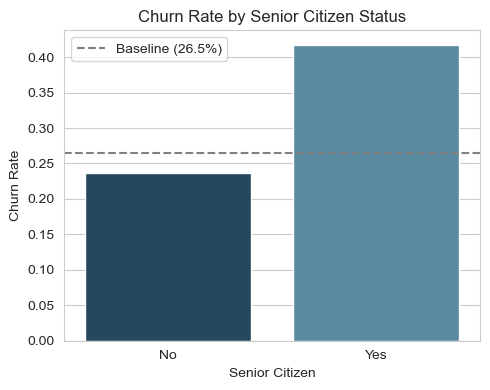

In [36]:
plt.figure(figsize=(5, 4))
sns.barplot(x=senior_churn.index, y='Churn Rate', data=senior_churn.reset_index(), palette=PALETTE)
plt.axhline(baseline_churn, color='grey', linestyle='--', label=f'Baseline ({baseline_churn:.1%})')
plt.title('Churn Rate by Senior Citizen Status')
plt.legend()
plt.tight_layout()
plt.show()

**Senior citizens churn at 41.7%** vs 23.6% for non-seniors — well above baseline, clear demographic signal in the data.

### Family Makeup

`Partner`, `Dependents` and `Senior Citizen` are combined into a single household-structure field, so we can look at household type.

In [39]:
def family_makeup(row):
    senior = row['Senior Citizen'] == 'Yes'
    partner = row['Partner'] == 'Yes'
    dependents = row['Dependents'] == 'Yes'

    if dependents and partner:
        return 'Family (Couple + Dependents)'
    elif dependents and not partner:
        return 'Single Parent'
    elif partner and not dependents:
        return 'Couple, No Dependents'
    elif senior:
        return 'Senior, Living Alone'
    else:
        return 'Single, No Dependents'

df_raw['Family_Makeup'] = df_raw.apply(family_makeup, axis=1)

family_churn = df_raw.groupby('Family_Makeup')['Churn Value'].agg(['count', 'mean']).rename(columns={'mean': 'Churn Rate'})
family_churn['Churn Rate'] = family_churn['Churn Rate'].round(4)
family_churn.sort_values('Churn Rate', ascending=False)

,count,Churn Rate
Family_Makeup,,
"Senior, Living Alone",558,0.4892
"Single, No Dependents",2781,0.3154
"Couple, No Dependents",2077,0.2951
Single Parent,302,0.1656
Family (Couple + Dependents),1325,0.0423


C:\Users\thetz\AppData\Local\Temp\ipykernel_33872\3922909926.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=family_churn.loc[order, 'Churn Rate'], y=order, palette=PALETTE)


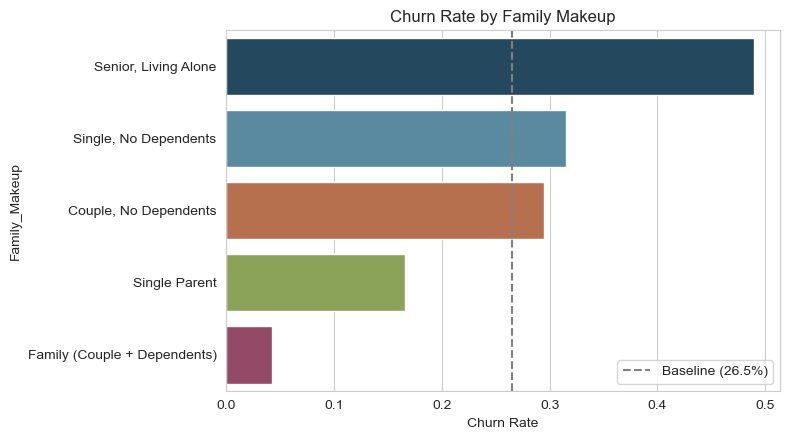

In [40]:
plt.figure(figsize=(8, 4.5))
order = family_churn.sort_values('Churn Rate', ascending=False).index
sns.barplot(x=family_churn.loc[order, 'Churn Rate'], y=order, palette=PALETTE)
plt.axvline(baseline_churn, color='grey', linestyle='--', label=f'Baseline ({baseline_churn:.1%})')
plt.title('Churn Rate by Family Makeup')
plt.xlabel('Churn Rate')
plt.legend()
plt.tight_layout()
plt.show()

important signal in our data: **Household structure matters far more than gender or age alone**.
- **Seniors living alone churn at 48.9%** — nearly double the baseline, and the highest of any group.
- **Singles with no dependents (31.5%) and couples with no dependents (29.5%)** above the baseline.
- **Single parents (16.6%) and especially families with a partner and dependents (4.2%)** churn far *below* baseline — households with dependents are, by a wide margin, the most stable customer group.

### Tenure


In [41]:
churned = df[df['Churn Value'] == 1]
retained = df[df['Churn Value'] == 0]

print("Churned customers - Tenure Months:")
print(churned['Tenure Months'].describe()[['mean', '50%', 'min', 'max']])
print("\nRetained customers - Tenure Months:")
print(retained['Tenure Months'].describe()[['mean', '50%', 'min', 'max']])

Churned customers - Tenure Months:
mean    17.979133
50%     10.000000
min      1.000000
max     72.000000
Name: Tenure Months, dtype: float64

Retained customers - Tenure Months:
mean    37.569965
50%     38.000000
min      0.000000
max     72.000000
Name: Tenure Months, dtype: float64


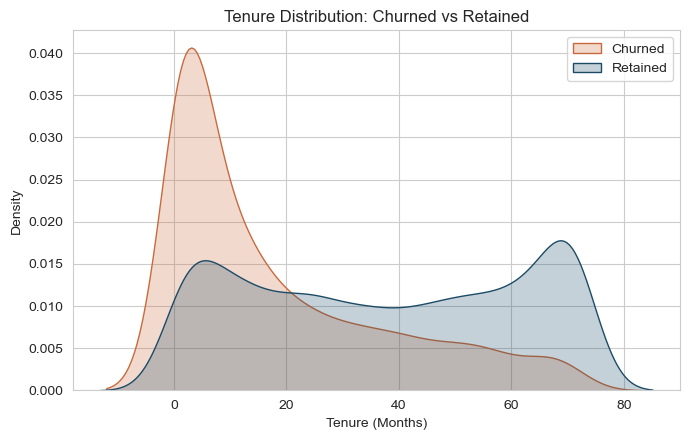

In [42]:
plt.figure(figsize=(7, 4.5))
sns.kdeplot(churned['Tenure Months'], fill=True, label='Churned', color=PALETTE[2])
sns.kdeplot(retained['Tenure Months'], fill=True, label='Retained', color=PALETTE[0])
plt.title('Tenure Distribution: Churned vs Retained')
plt.xlabel('Tenure (Months)')
plt.legend()
plt.tight_layout()
plt.show()

Churners have a median tenure of just 10 months vs 38 months for retained customers — churn is heavily concentrated in the first year, (though long tail out to 72 months shows some long-tenured customers do still leave.)

Same data shown as a grouped bar chart across tenure buckets:

C:\Users\thetz\AppData\Local\Temp\ipykernel_33872\33545782.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn_counts = df.groupby(['Tenure_Group', 'Churn Value']).size().unstack(fill_value=0)


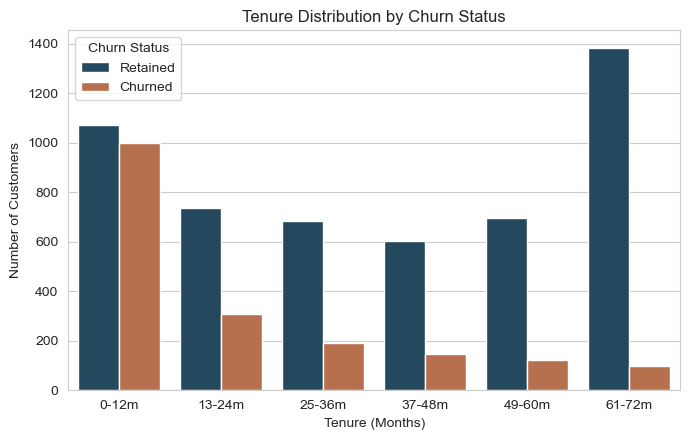

In [43]:


# tenure bins and labels
bins = [0, 12, 24, 36, 48, 60, 75]
labels = ['0-12m', '13-24m', '25-36m', '37-48m', '49-60m', '61-72m']
df['Tenure_Group'] = pd.cut(df['Tenure Months'], bins=bins, labels=labels, right=False)

# Group by Tenure_Group and Churn Value, then count
tenure_churn_counts = df.groupby(['Tenure_Group', 'Churn Value']).size().unstack(fill_value=0)

# 3. Rename columns for Churn Value
tenure_churn_counts.columns = ['Retained', 'Churned'] # 0 is Retained, 1 is Churned
tenure_churn_melted = tenure_churn_counts.reset_index().melt(id_vars='Tenure_Group', var_name='Churn Status', value_name='Count')

# Order the 'Churn Status' for consistent plotting
tenure_churn_melted['Churn Status'] = pd.Categorical(tenure_churn_melted['Churn Status'], categories=['Retained', 'Churned'], ordered=True)

# Order the 'Tenure_Group' for consistent plotting using the new labels
tenure_churn_melted['Tenure_Group'] = pd.Categorical(tenure_churn_melted['Tenure_Group'], categories=labels, ordered=True)
tenure_churn_melted = tenure_churn_melted.sort_values(['Tenure_Group', 'Churn Status'])


plt.figure(figsize=(7, 4.5))
sns.barplot(x='Tenure_Group', y='Count', hue='Churn Status', data=tenure_churn_melted, palette=[PALETTE[0], PALETTE[2]])
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn Status')
plt.tight_layout()
plt.show()

## 2. What Products Do Churners Have?

### Internet Service, Contract & Payment Method

In [45]:
for col in ['Internet Service', 'Contract', 'Payment Method']:
    tbl = df_raw.groupby(col)['Churn Value'].agg(['count', 'mean']).rename(columns={'mean': 'Churn Rate'})
    tbl['Churn Rate'] = tbl['Churn Rate'].round(4)
    print(f"--- {col} ---")
    print(tbl.sort_values('Churn Rate', ascending=False))
    print()

--- Internet Service ---
                  count  Churn Rate
Internet Service                   
Fiber optic        3096      0.4189
DSL                2421      0.1896
No                 1526      0.0740

--- Contract ---
                count  Churn Rate
Contract                         
Month-to-month   3875      0.4271
One year         1473      0.1127
Two year         1695      0.0283

--- Payment Method ---
                           count  Churn Rate
Payment Method                              
Electronic check            2365      0.4529
Mailed check                1612      0.1911
Bank transfer (automatic)   1544      0.1671
Credit card (automatic)     1522      0.1524



C:\Users\thetz\AppData\Local\Temp\ipykernel_33872\1715123311.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tbl.values, y=tbl.index, ax=ax, palette=PALETTE)
C:\Users\thetz\AppData\Local\Temp\ipykernel_33872\1715123311.py:4: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(x=tbl.values, y=tbl.index, ax=ax, palette=PALETTE)
C:\Users\thetz\AppData\Local\Temp\ipykernel_33872\1715123311.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tbl.values, y=tbl.index, ax=ax, palette=PALETTE)
C:\Users\thetz\AppData\Local\Temp\ipykernel_33872\1715123311.py:4: UserWarning: The palette list has more values (5) than needed (3), which may 

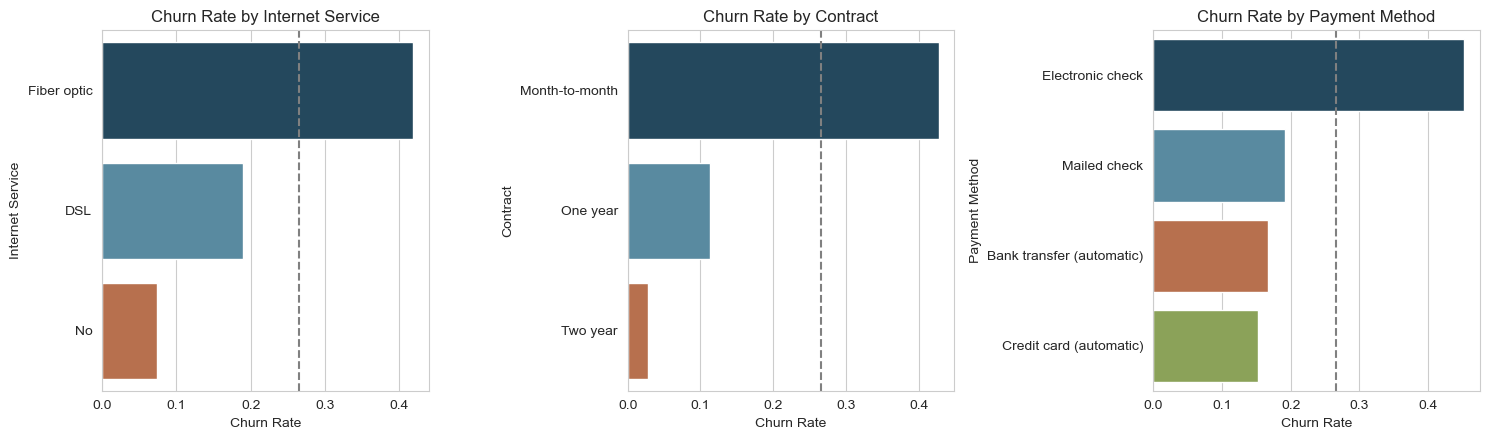

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['Internet Service', 'Contract', 'Payment Method']):
    tbl = df_raw.groupby(col)['Churn Value'].mean().sort_values(ascending=False)
    sns.barplot(x=tbl.values, y=tbl.index, ax=ax, palette=PALETTE)
    ax.axvline(baseline_churn, color='grey', linestyle='--')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('Churn Rate')
plt.tight_layout()
plt.show()

- **Fiber optic customers churn at 41.9%**, almost double DSL (19.0%) and nearly six times customers with no internet service (7.4%)

- **Month-to-month customers churn at 42.7%**, vs 11.3% (one year) and just 2.8% (two year) — contract length is a very strong retention lever
- **Electronic check payers churn at 45.3%**, well above the other three payment methods (all 15–19%)



## 3. Why Are Churners Churning?

`Churn Reason` is only populated for churned customers. `"Don't know"` is excluded below as non-actionable. `"Moved"`and `"Deceased"` are also excluded as non- actionable

In [62]:
EXCLUDE_REASONS = ["Don't know"]
NON_ACTIONABLE = ["Moved", "Deceased"]
churned = df_raw[df_raw['Churn Value'] == 1]
actionable = churned.copy()
actionable = actionable[~actionable['Churn Reason'].isin(EXCLUDE_REASONS)]
actionable = actionable[~actionable['Churn Reason'].isin(NON_ACTIONABLE)]

reason_counts = actionable['Churn Reason'].value_counts()

print(
    f"{len(actionable)} of {len(churned)} churned customers gave an actionable reason "
    f"({len(churned) - len(actionable)} said \"Don't know\")"
)

reason_counts


1656 of 1869 churned customers gave an actionable reason (213 said "Don't know")


Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Limited range of services                     44
Lack of affordable download/upload speed      44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Name: count, dtype: int64

C:\Users\thetz\AppData\Local\Temp\ipykernel_33872\3891189054.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_counts.values, y=reason_counts.index, palette=PALETTE * 4)
C:\Users\thetz\AppData\Local\Temp\ipykernel_33872\3891189054.py:2: UserWarning: The palette list has more values (20) than needed (17), which may not be intended.
  sns.barplot(x=reason_counts.values, y=reason_counts.index, palette=PALETTE * 4)


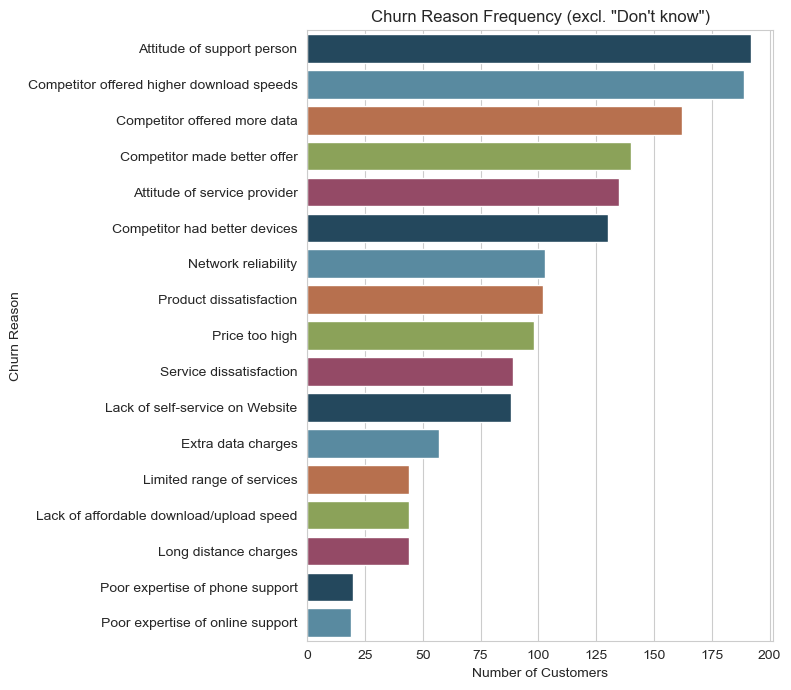

In [63]:
plt.figure(figsize=(8, 7))
sns.barplot(x=reason_counts.values, y=reason_counts.index, palette=PALETTE * 4)
plt.title("Churn Reason Frequency (excl. \"Don't know\")")
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()

**Attitude of support person** (192) and **Competitor offered higher download speeds** (189) are the two single most common reasons, closely followed by **Competitor offered more data** (162) and **Competitor made better offer** (140).

### Grouping into Product / Service / Market / Price Classification

Each `Churn Reason` is mapped to a broader driver category so we can ask, are customers leaving because of the **product** (infrastructure, features), the **service experience** (support quality, self-service), the **market** (a competitor's offer), or **price**?



In [64]:
CATEGORY_MAP = {
    'Competitor offered higher download speeds': 'Market-Driven',
    'Competitor offered more data': 'Market-Driven',
    'Competitor made better offer': 'Market-Driven',
    'Competitor had better devices': 'Market-Driven',
    'Attitude of support person': 'Service-Driven',
    'Attitude of service provider': 'Service-Driven',
    'Service dissatisfaction': 'Service-Driven',
    'Lack of self-service on Website': 'Service-Driven',
    'Poor expertise of phone support': 'Service-Driven',
    'Poor expertise of online support': 'Service-Driven',
    'Network reliability': 'Product-Driven',
    'Product dissatisfaction': 'Product-Driven',
    'Limited range of services': 'Product-Driven',
    'Lack of affordable download/upload speed': 'Product-Driven',
    'Price too high': 'Price-Driven',
    'Extra data charges': 'Price-Driven',
    'Long distance charges': 'Price-Driven',
    'Moved': 'Non-Actionable',
    'Deceased': 'Non-Actionable',
}

actionable = actionable.copy()
actionable['Reason_Category'] = actionable['Churn Reason'].map(CATEGORY_MAP)
assert actionable['Reason_Category'].isna().sum() == 0, "Unmapped churn reason - update CATEGORY_MAP"

category_pct = actionable['Reason_Category'].value_counts(normalize=True)
category_pct.round(3)

Reason_Category
Market-Driven     0.375
Service-Driven    0.328
Product-Driven    0.177
Price-Driven      0.120
Name: proportion, dtype: float64

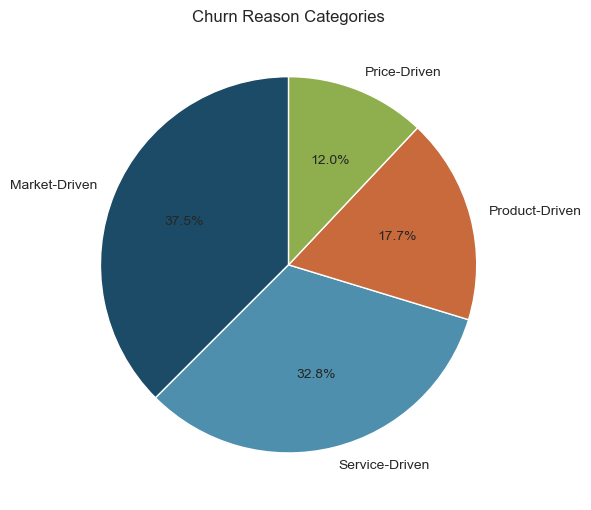

In [65]:
plt.figure(figsize=(6, 6))
plt.pie(category_pct.values, labels=category_pct.index, autopct='%1.1f%%',
        colors=PALETTE[:len(category_pct)], startangle=90)
plt.title('Churn Reason Categories')
plt.tight_layout()
plt.show()

**Market-driven reasons (37.5%) are the single largest category** — customers are most often leaving because a competitor offered something better (speed, data, devices, or a general better offer) — followed closely by **Service-driven reasons (32.8%)**. **Product-driven (17.7%)** and **Price-driven (12%)** are smaller but still meaningful.

In [66]:
print("Top 3 reasons - Fiber optic customers:")
print(actionable[actionable['Internet Service'] == 'Fiber optic']['Churn Reason'].value_counts().head(3))
print()
print("Top 3 reasons - DSL customers:")
print(actionable[actionable['Internet Service'] == 'DSL']['Churn Reason'].value_counts().head(3))
print()
print("Top 3 reasons - Month-to-month contract customers:")
print(actionable[actionable['Contract'] == 'Month-to-month']['Churn Reason'].value_counts().head(3))

Top 3 reasons - Fiber optic customers:
Churn Reason
Attitude of support person                   133
Competitor offered higher download speeds    130
Competitor offered more data                 120
Name: count, dtype: int64

Top 3 reasons - DSL customers:
Churn Reason
Competitor offered higher download speeds    51
Competitor had better devices                44
Attitude of support person                   41
Name: count, dtype: int64

Top 3 reasons - Month-to-month contract customers:
Churn Reason
Attitude of support person                   174
Competitor offered higher download speeds    161
Competitor offered more data                 140
Name: count, dtype: int64


 **Fiber optic** customers (41.9% churn rate, the highest of any internet type) most often cite **support attitude** and **competitors offering higher download speeds / more data** — plausible, since fiber is Swan Teleco's premium, highest-expectation tier: customers paying the most for speed are the most sensitive to a competitor beating them on exactly that dimension, and to a support interaction that doesn't match the premium price.
- **DSL** customers instead lead with **competitor offered higher download speeds** and **competitor had better devices** — consistent with DSL being the lower-bandwidth tier: these customers are plausibly leaving for a straightforward infrastructure upgrade elsewhere (e.g. to a competitor's fiber), a **product-driven** switch rather than a service complaint.
- **Month-to-month** customers (42.7% churn, by far the highest of the three contract types) lead with **support attitude** and **competitor speed/data offers** — with no contract lock-in, there's nothing holding them through a bad support interaction or a better competing offer, so service and market factors convert into an actual cancellation far more easily than for contracted customers.
- The **Senior, Living Alone** and **Single, No Dependents** groups identified in Section 1 as the highest-churning household types are also disproportionately on month-to-month contracts without security/support add-ons (Section 2) — so the "who" and "why" line up: less-locked-in, less-supported customers churn the most, and cite service/market reasons the most.

## Summary

**Demographics:** gender doesn't matter; senior citizens and (even more so) seniors/singles living alone churn well above baseline, while households with dependents are the most stable. Churn is concentrated in the first year of tenure (median 10 months vs 38 for retained).

**Products:** fiber optic, month-to-month contracts, and electronic check payment are the three strongest product-level churn signals. Security/support add-ons (Online Security especially) are strongly associated with lower churn — customers without them churn nearly 3x as often as customers with them.

**Why:** Market-driven (competitor offers) and Service-driven (support attitude/expertise) reasons dominate, together accounting for roughly two-thirds of all actionable churn reasons. Product-driven and Price-driven reasons matter more for specific groups (DSL customers, respectively long-tenured high-bill customers).


**Limitations **
`Churn Reason` is self-reported at time of cancellation and may not capture every customer's true motivation.

all of the above is descriptive/correlational (grouped comparisons and cross-tabs), not a controlled experiment or a model — it's suited to prioritising where to focus retention effort and messaging, not to proving a single causal mechanism.






## Additional: churn-reason categories by household type

In [67]:
# Calculate the joint distribution of Family_Makeup and Reason_Category for actionable churners
cross_tab = pd.crosstab(actionable['Family_Makeup'], actionable['Reason_Category'])

# Convert to proportions within each Family_Makeup group (row-wise sum to 1)
category_proportion_by_family = cross_tab.div(cross_tab.sum(axis=1), axis=0)

# Calculate the lift
# Lift = (Proportion of reason category in family group) / (Overall proportion of reason category)
# Ensure that category_pct is aligned correctly to Reason_Category columns
category_lift_df = category_proportion_by_family.div(category_pct, axis=1)

This heatmap shows the 'lift' of each churn reason category across different houshold category.

 A value greater than 1 - that group is more likely to churn for that particular reason category compared to the overall churned population. Conversely, a value less than 1 indicates they are less likely.

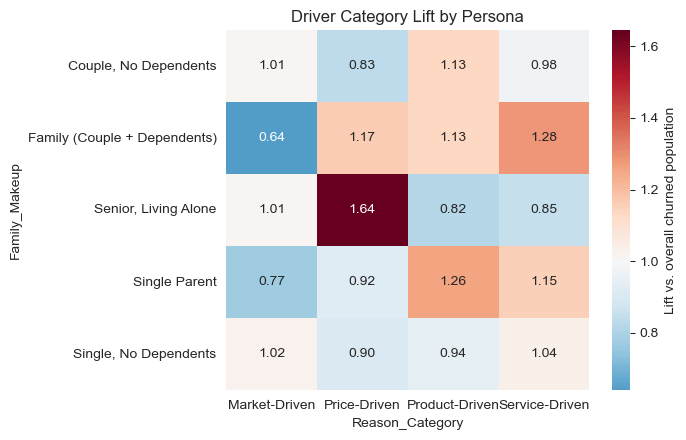

In [70]:
plt.figure(figsize=(7, 4.5))
sns.heatmap(category_lift_df, annot=True, fmt='.2f', cmap='RdBu_r', center=1.0,
            cbar_kws={'label': 'Lift vs. overall churned population'})
plt.title('Driver Category Lift by Persona')
plt.tight_layout()
plt.show()

Senior, Living Alone' customers have a high lift for 'Price-Driven' reasons (1.64), meaning they are significantly more likely to churn due to price issues.

Values less than 1 (bluer shades) indicate that customers in that Family_Makeup group are less likely to churn for that Reason_Category compared to the overall average. For instance, 'Family (Couple + Dependents)' has a low lift for 'Market-Driven' reasons (0.64), suggesting they are less influenced by competitor offers than other groups.

# 3. Q2 — Retention Factors and the £2.50 Sign-up Incentive

**What makes a customer more likely to stay?** The descriptive analysis in Section 2 gives the answer directly — the strongest retention signals (in order of separation from baseline) are:

- **Two-year contracts** — 2.8% churn vs 42.7% for month-to-month.
- **Longer tenure** — retained-customer median tenure is 38 months vs 10 for churners; risk collapses after the first year.
- **Households with dependents** — families with a partner and dependents churn at just 4.2%.
- **DSL or no internet service** — 19.0% and 7.4% churn respectively, vs 41.9% for fiber optic.
- **Automatic payment methods** — bank transfer / credit-card auto-pay sit at 15–19% vs 45.3% for electronic check.
- **Service add-ons** — Online Security, Tech Support, Online Backup, Device Protection are all associated with materially lower churn.

**Best-case sign-up profile to brief the new-customer team:** two-year contract, automatic payment, DSL where fiber isn't required, and at least one add-on (ideally Online Security).

**Which single factor should get the £2.50 incentive?** The rest of this section quantifies the retention impact of each add-on service to pick the one the incentive spend should be pointed at.

## £2.50 sign-up incentive — which service should we push?

We can pay the sales team £2.50 for every customer they sign up to one specific service. The goal is to pick the service where that spend does the most to reduce churn.

## Define the incentive and the services to test

`INCENTIVE` is the £2.50 per signup from the brief, kept as a named constant so we only edit one place if the amount changes.

`signup_factors` is the list of services eligible for the incentive. We'll loop through this list and calculate the same metrics for each one.


In [71]:
INCENTIVE = 2.50  # £ per signup paid to sales team

signup_factors = ['Phone Service', 'Multiple Lines', 'Internet Service',
                  'Online Security', 'Online Backup', 'Device Protection',
                  'Tech Support', 'Streaming TV', 'Streaming Movies']


## Score each service

For every service in the list, we split customers into two groups and compare their churn rates:

- **Have it** (`'Yes'`) — already subscribed.
- **Addressable** (`'No'`) — don't have it but *could*. We match exactly `'No'` so the `'No internet service'` / `'No phone service'` customers (who aren't eligible) are excluded.

Then we calculate:

| Metric | What it means |
|---|---|
| **Churn % with** | Churn rate among customers who already have the service |
| **Churn % without** | Churn rate among the addressable market |
| **Gap (pp)** | Difference in percentage points — how much churn drops when a customer has this service |
| **Est. saves if all convert** | Addressable × (gap / 100) — theoretical customers retained if you signed everyone up |
| **Cost per save (£)** | Total incentive spend ÷ estimated saves — how much you effectively pay per retained customer |



In [74]:
rows = []
for svc in signup_factors:
    has_it     = df_raw[df_raw[svc] == 'Yes']

    could_have = df_raw[df_raw[svc] == 'No']

    n_have = len(has_it)
    n_addressable = len(could_have)
    churn_with    = has_it['Churn Value'].mean() * 100 if n_have else np.nan
    churn_without = could_have['Churn Value'].mean() * 100 if n_addressable else np.nan
    gap_pp = churn_without - churn_with
    est_saves = n_addressable * (gap_pp / 100) if gap_pp > 0 else 0
    cost_per_save = (n_addressable * INCENTIVE) / est_saves if est_saves > 0 else np.nan

    rows.append({
        'Service': svc,
        'Have it (n)': n_have,
        'Addressable (n)': n_addressable,
        'Churn % with': round(churn_with, 1),
        'Churn % without': round(churn_without, 1),
        'Gap (pp)': round(gap_pp, 1),
        'Est. saves if all convert': round(est_saves, 0),
        'Cost per save (£)': round(cost_per_save, 2),
    })


## Build the ranking table

Turn the list of dictionaries into a dataframe and sort so the biggest retention impact appears at the top. The service with the most estimated saves is our recommended target for the incentive.


In [75]:
ranking = pd.DataFrame(rows).sort_values('Est. saves if all convert', ascending=False)
ranking


,Service,Have it (n),Addressable (n),Churn % with,Churn % without,Gap (pp),Est. saves if all convert,Cost per save (£)
3,Online Security,2019,3498,14.6,41.8,27.2,950.0,9.21
6,Tech Support,2044,3473,15.2,41.6,26.5,919.0,9.44
4,Online Backup,2429,3088,21.5,39.9,18.4,568.0,13.59
5,Device Protection,2422,3095,22.5,39.1,16.6,515.0,15.04
8,Streaming Movies,2732,2785,29.9,33.7,3.7,104.0,66.86
7,Streaming TV,2707,2810,30.1,33.5,3.5,97.0,72.40
0,Phone Service,6361,682,26.7,24.9,-1.8,0.0,NaN
1,Multiple Lines,2971,3390,28.6,25.0,-3.6,0.0,NaN
2,Internet Service,0,1526,NaN,7.4,NaN,0.0,NaN


## Visualise the ranking

Two side-by-side bar charts:

- **Left:** estimated customers retained per service — the winner is highlighted in dark blue.
- **Right:** effective cost per retained customer (lower = better) — the most cost-efficient service is highlighted in dark blue.

We filter to services with a positive gap (`Est. saves > 0`) so we don't clutter the chart with services that correlate *negatively* with retention.


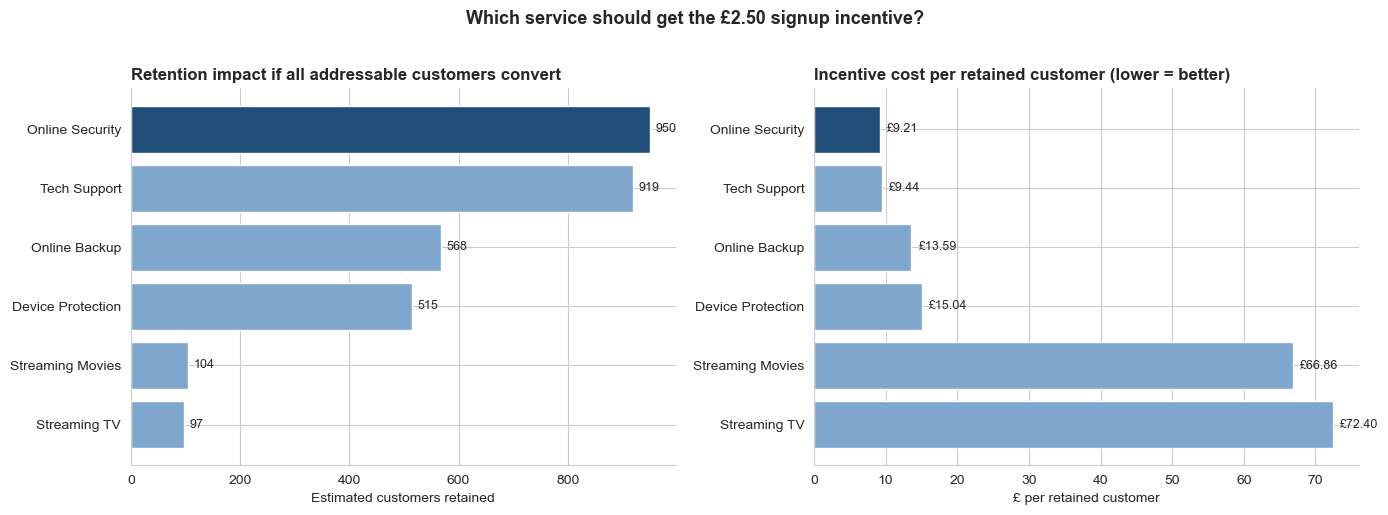

In [76]:
plot_df = ranking[ranking['Est. saves if all convert'] > 0].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1f4e79' if v == plot_df['Est. saves if all convert'].max() else '#7fa6cc'
          for v in plot_df['Est. saves if all convert']]
ax1.barh(plot_df['Service'], plot_df['Est. saves if all convert'],
         color=colors, edgecolor='white')
ax1.invert_yaxis()
ax1.set_xlabel('Estimated customers retained')
ax1.set_title('Retention impact if all addressable customers convert',
              fontweight='bold', loc='left')
for i, v in enumerate(plot_df['Est. saves if all convert']):
    ax1.text(v + 10, i, f'{int(v)}', va='center', fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

colors = ['#1f4e79' if v == plot_df['Cost per save (£)'].min() else '#7fa6cc'
          for v in plot_df['Cost per save (£)']]
ax2.barh(plot_df['Service'], plot_df['Cost per save (£)'],
         color=colors, edgecolor='white')
ax2.invert_yaxis()
ax2.set_xlabel('£ per retained customer')
ax2.set_title('Incentive cost per retained customer (lower = better)',
              fontweight='bold', loc='left')
for i, v in enumerate(plot_df['Cost per save (£)']):
    ax2.text(v + 1, i, f'£{v:.2f}', va='center', fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Which service should get the £{INCENTIVE:.2f} signup incentive?',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# 4. Q3 — 500 Mailers: Which Customers to Target

**Method.** Score every currently-retained customer (`Churn Value == 0`) with the `best_model` from Section 1, then take the 500 customers with the highest predicted churn probability. This is exactly what the custom precision@top-7.1% metric in the grid search was tracking, so the cross-validated performance on that slice is our best estimate of how the mailer list will convert.


**Deliverable.** Sort `X` (the full retained population) by `best_model.predict_proba(...)[:, 1]` descending and take the top 500 `CustomerID`s. This is the list to hand to the mailer team.

**Score all remaining customers.** We first filter to retained customers only (`Churn Value == 0`) and score them with `best_HGB.predict_proba`. The resulting `predicted_prob_churn` DataFrame is used both for the top-500 export below (Q3) and for the full risk list in Section 5 (Q4).

In [77]:
best_HGB = HistGradientBoostingClassifier(min_samples_leaf=100, max_iter=300, max_depth=5, learning_rate=0.05, class_weight=None, random_state=42)
best_HGB.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,5
,min_samples_leaf,100
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [78]:
current_customers_clean = df[df['Churn Value'] == 0].drop("Churn Value", axis = 1)
current_customers_raw = df_raw[df_raw['Churn Value'] == 0]

In [79]:
preds = best_HGB.predict_proba(current_customers_clean)[:, 1]
print(preds)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Family_Makeup
- Tenure_Group


In [ ]:
predicted_prob_churn = pd.DataFrame()
predicted_prob_churn["Customer ID"] = current_customers_raw["CustomerID"]
predicted_prob_churn["Probability of Churning"] = best_HGB.predict_proba(current_customers_clean)[:, 1]
predicted_prob_churn.head()

**Top 500 mailer list.** Sort by predicted churn probability descending, take the top 500, drop the probability column, and export as `Most Likely Churners.csv`.

In [ ]:
most_likely_churners = predicted_prob_churn.sort_values("Probability of Churning", ascending = False).head(500).drop("Probability of Churning", axis = 1)

In [ ]:
most_likely_churners.to_csv("Most Likely Churners.csv", index = False)

# 5. Q4 — Churn Risk for All Remaining Customers


**Full risk list export.** Uses the `predicted_prob_churn` DataFrame already built in Section 4 — every retained customer with their Customer ID and predicted churn probability. Exported as `Model Predictions.csv` for the customer-service team.

In [80]:
predicted_prob_churn.to_csv("Model Predictions.csv", index = False)

NameError: name 'predicted_prob_churn' is not defined